# Experiment 1: Implementation of a Single Layer Perceptron for Binary Classification

**Course:** CS3807 – Deep Learning Laboratory  
**Programme:** B.Tech Artificial Intelligence & Data Science, Semester V  
**AY:** 2026–27

**Dataset:** Banknote Authentication Dataset (UCI Machine Learning Repository)

This notebook implements a Single Layer Perceptron **from scratch** (no ML library used for the
core algorithm) for binary classification of genuine vs. forged banknotes, following the
experimental procedure of the lab manual.

## 0. Setup: Imports, Plot Style & Output Directory

In [1]:

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay)

# ---- Professional, print-friendly colour palette ----
PALETTE = ["#2C3E50", "#C0392B", "#2980B9", "#27AE60", "#8E44AD", "#D68910"]
sns.set_palette(PALETTE)

# ---- Global plot style: small figures, bold axis labels & legends, publication quality ----
mpl.rcParams.update({
    "figure.figsize": (4.5, 3.3),      # compact figure size
    "savefig.dpi": 600,                # high resolution for saved files
    "figure.dpi": 100,                 # comfortable on-screen rendering
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.titleweight": "bold",
    "axes.labelsize": 9,
    "axes.labelweight": "bold",        # bold x & y axis labels
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "legend.title_fontsize": 8,
    "axes.edgecolor": "#333333",
    "axes.linewidth": 0.8,
    "grid.alpha": 0.3,
    "grid.linewidth": 0.5,
    "font.family": "DejaVu Sans",
})

# Directory to store all EPS plots (600 DPI, small physical size)
PLOT_DIR = "plots"
os.makedirs(PLOT_DIR, exist_ok=True)

def save_fig(fig, name):
    '''Save a figure as a 600-DPI EPS file with a bold legend (if present) and tight layout.'''
    for ax in fig.get_axes():
        leg = ax.get_legend()
        if leg is not None:
            leg.set_title(leg.get_title().get_text())
            if leg.get_title().get_text():
                leg.get_title().set_fontweight("bold")
            for text in leg.get_texts():
                text.set_fontweight("bold")
    fig.tight_layout()
    fig.savefig(os.path.join(PLOT_DIR, f"{name}.eps"), format="eps", dpi=600, bbox_inches="tight")
    print(f"Saved: {PLOT_DIR}/{name}.eps  (600 DPI)")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Unified colormaps (built from the same PALETTE) for heatmap / confusion matrix / boundary
from matplotlib.colors import LinearSegmentedColormap
DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "report_diverging", ["#C0392B", "#F4EDE4", "#2C3E50"]
)
SEQUENTIAL_CMAP = LinearSegmentedColormap.from_list(
    "report_sequential", ["#F4EDE4", "#2C3E50"]
)


## Task 1: Dataset Exploration

Load the Banknote Authentication dataset, display the first five samples, determine
dataset dimensions, identify missing values, and display descriptive statistics.

In [2]:

# Load dataset (local file: data_banknote_authentication.txt, comma-separated, no header)
COLUMN_NAMES = ["Variance", "Skewness", "Curtosis", "Entropy", "Class"]
DATA_PATH = "data_banknote_authentication.txt"

df = pd.read_csv(DATA_PATH, header=None, names=COLUMN_NAMES)
print("Dataset loaded successfully.")
df.head()


Dataset loaded successfully.


,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [3]:

print(f"Dataset dimensions (rows, columns): {df.shape}")


Dataset dimensions (rows, columns): (1372, 5)


In [4]:

print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


Missing values per column:
Variance    0
Skewness    0
Curtosis    0
Entropy     0
Class       0
dtype: int64

Total missing values: 0


In [5]:

print("Descriptive statistics:")
df.describe()


Descriptive statistics:


,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [6]:

print("Class distribution:")
class_counts = df["Class"].value_counts().sort_index()
class_counts.index = ["0 - Authentic", "1 - Forged"]
print(class_counts)


Class distribution:
0 - Authentic    762
1 - Forged       610
Name: count, dtype: int64


## Task 2: Exploratory Data Analysis

Generate histograms, a correlation heatmap, a scatter plot, and boxplots for the four
numerical features.

### 2.1 Feature Histograms — Distribution Analysis

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/01_feature_histograms.eps  (600 DPI)


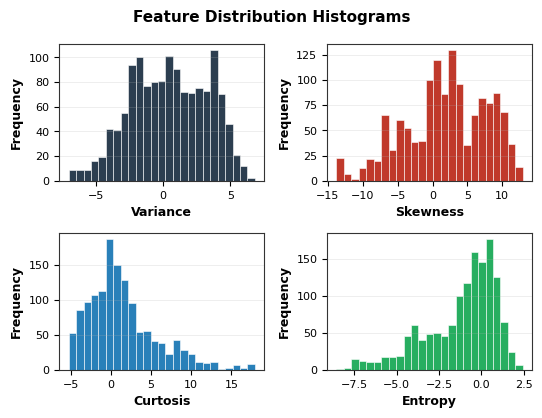

In [7]:

fig, axes = plt.subplots(2, 2, figsize=(5.5, 4.2))
features = ["Variance", "Skewness", "Curtosis", "Entropy"]

for ax, feat, color in zip(axes.ravel(), features, PALETTE):
    ax.hist(df[feat], bins=25, color=color, edgecolor="white", linewidth=0.4)
    ax.set_xlabel(feat, fontweight="bold")
    ax.set_ylabel("Frequency", fontweight="bold")
    ax.grid(axis="y")

fig.suptitle("Feature Distribution Histograms", fontweight="bold", fontsize=11)
save_fig(fig, "01_feature_histograms")
plt.show()


**Inference:** Variance and Skewness show a fairly spread, roughly symmetric distribution,
while Curtosis and Entropy exhibit noticeable skewness with a longer tail and a few potential
outliers. This asymmetry motivates the normalization step performed later.

### 2.2 Correlation Heatmap — Feature Relationships

Saved: plots/02_correlation_heatmap.eps  (600 DPI)


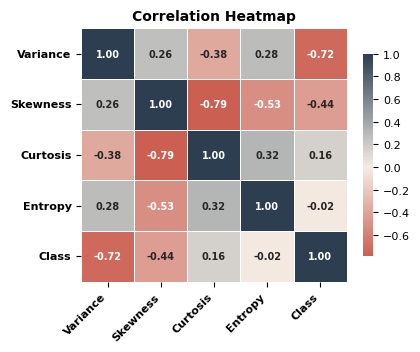

In [8]:

fig, ax = plt.subplots(figsize=(4.3, 3.6))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap=DIVERGING_CMAP, center=0,
            linewidths=0.5, linecolor="white", cbar_kws={"shrink": 0.8}, ax=ax,
            annot_kws={"fontsize": 7, "fontweight": "bold"})
ax.set_xticklabels(ax.get_xticklabels(), fontweight="bold", rotation=45, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), fontweight="bold", rotation=0)
ax.set_title("Correlation Heatmap", fontweight="bold")
save_fig(fig, "02_correlation_heatmap")
plt.show()


**Inference:** Variance shows the strongest (negative) correlation with the target Class,
indicating it is the most discriminative single feature. Skewness and Curtosis are moderately
correlated with each other, while Entropy correlates weakly with the remaining features.

### 2.3 Scatter Plot — Class Distribution

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/03_scatter_class_distribution.eps  (600 DPI)


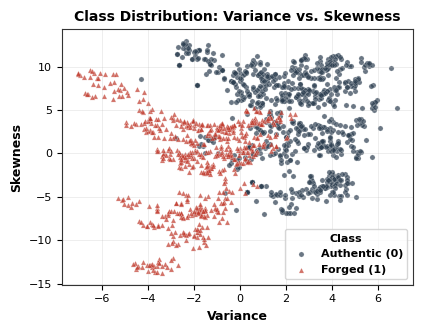

In [9]:

fig, ax = plt.subplots(figsize=(4.3, 3.4))
for cls, label, color, marker in zip([0, 1], ["Authentic (0)", "Forged (1)"],
                                      PALETTE[:2], ["o", "^"]):
    subset = df[df["Class"] == cls]
    ax.scatter(subset["Variance"], subset["Skewness"], s=14, alpha=0.7,
               color=color, marker=marker, label=label, edgecolor="white", linewidth=0.2)

ax.set_xlabel("Variance", fontweight="bold")
ax.set_ylabel("Skewness", fontweight="bold")
ax.set_title("Class Distribution: Variance vs. Skewness", fontweight="bold")
ax.legend(title="Class", frameon=True)
ax.grid(True)
save_fig(fig, "03_scatter_class_distribution")
plt.show()


**Inference:** The two classes form largely distinguishable clusters along the Variance and
Skewness axes, suggesting the data is close to linearly separable — a condition under which a
perceptron is expected to perform well.

### 2.4 Boxplots — Outlier & Spread Analysis

/tmp/ipykernel_575/3997351062.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot([df[f] for f in features], labels=features, patch_artist=True,
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/04_boxplots.eps  (600 DPI)


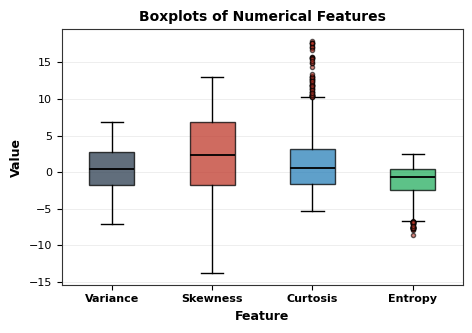

In [10]:

fig, ax = plt.subplots(figsize=(4.8, 3.4))
box = ax.boxplot([df[f] for f in features], labels=features, patch_artist=True,
                  medianprops=dict(color="black", linewidth=1.3),
                  flierprops=dict(marker="o", markersize=3, markerfacecolor="#C0392B", alpha=0.6))

for patch, color in zip(box["boxes"], PALETTE):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.set_xlabel("Feature", fontweight="bold")
ax.set_ylabel("Value", fontweight="bold")
ax.set_title("Boxplots of Numerical Features", fontweight="bold")
ax.set_xticklabels(features, fontweight="bold")
ax.grid(axis="y")
save_fig(fig, "04_boxplots")
plt.show()


**Inference:** Curtosis and Entropy display a wider interquartile range and more outliers
compared to Variance and Skewness, confirming the skew observed in the histograms and reinforcing
the need for feature normalization before training.

## Task 3: Data Preprocessing

Normalize all numerical features (zero mean, unit variance) and split the dataset into
Training (80%) and Testing (20%) sets.

In [11]:

X = df[features].values
y = df["Class"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set size : {X_train_scaled.shape}")
print(f"Testing set size  : {X_test_scaled.shape}")
print(f"Train class balance: {np.bincount(y_train)}")
print(f"Test  class balance: {np.bincount(y_test)}")


Training set size : (1097, 4)
Testing set size  : (275, 4)
Train class balance: [609 488]
Test  class balance: [153 122]


## Task 4: Perceptron Implementation (From Scratch)

Implements weight/bias initialization, the step activation function, forward propagation,
and the perceptron learning rule, without relying on any ML library for the core algorithm.

In [12]:

class SingleLayerPerceptron:
    '''A Single Layer Perceptron trained with the classical perceptron learning rule.'''

    def __init__(self, n_features, learning_rate=0.01, n_epochs=10, random_state=RANDOM_STATE):
        rng = np.random.default_rng(random_state)
        self.weights = rng.normal(loc=0.0, scale=0.01, size=n_features)  # Weight Initialization
        self.bias = 0.0                                                  # Bias Initialization
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.history = []   # per-epoch training log

    @staticmethod
    def step_activation(z):
        '''Step Activation Function: f(z) = 1 if z >= 0 else 0'''
        return np.where(z >= 0, 1, 0)

    def forward(self, x):
        '''Forward Propagation: z = w^T x + b ; y_hat = f(z)'''
        z = np.dot(x, self.weights) + self.bias
        return self.step_activation(z)

    def fit(self, X, y, verbose=True):
        n_samples = X.shape[0]
        for epoch in range(1, self.n_epochs + 1):
            misclassified = 0
            for xi, target in zip(X, y):
                y_hat = self.forward(xi)
                error = target - y_hat
                if error != 0:
                    misclassified += 1
                    # Perceptron Learning Rule
                    self.weights += self.lr * error * xi
                    self.bias += self.lr * error

            train_error_rate = misclassified / n_samples
            self.history.append({
                "epoch": epoch,
                "misclassified": misclassified,
                "error_rate": train_error_rate,
                "weights": self.weights.copy(),
                "bias": self.bias,
            })
            if verbose:
                w_str = ", ".join(f"{w:.4f}" for w in self.weights)
                print(f"Epoch {epoch:>3} | Misclassified: {misclassified:>4} | "
                      f"Weights: [{w_str}] | Bias: {self.bias:.4f}")
        return self

    def predict(self, X):
        return self.forward(X)


## Task 5: Model Training

Train the perceptron on the training set using the perceptron learning rule, displaying the
epoch number, number of misclassified samples, updated weights, and updated bias at every epoch.

In [13]:

LEARNING_RATE = 0.1
N_EPOCHS = 10

perceptron = SingleLayerPerceptron(
    n_features=X_train_scaled.shape[1],
    learning_rate=LEARNING_RATE,
    n_epochs=N_EPOCHS,
    random_state=RANDOM_STATE,
)
perceptron.fit(X_train_scaled, y_train, verbose=True)


Epoch   1 | Misclassified:   48 | Weights: [-0.7233, -0.7334, -0.4561, -0.0008] | Bias: -0.2000
Epoch   2 | Misclassified:   32 | Weights: [-0.7601, -0.8395, -0.8141, -0.0058] | Bias: -0.4000
Epoch   3 | Misclassified:   27 | Weights: [-0.7936, -1.0341, -0.9049, 0.0640] | Bias: -0.5000
Epoch   4 | Misclassified:   22 | Weights: [-0.8897, -1.1181, -0.9756, 0.0893] | Bias: -0.5000
Epoch   5 | Misclassified:   23 | Weights: [-0.8710, -1.1543, -1.0441, 0.0515] | Bias: -0.6000
Epoch   6 | Misclassified:   29 | Weights: [-1.0527, -1.2382, -1.1397, 0.0448] | Bias: -0.5000
Epoch   7 | Misclassified:   17 | Weights: [-1.1172, -1.2671, -1.1408, 0.0667] | Bias: -0.6000
Epoch   8 | Misclassified:   24 | Weights: [-1.0592, -1.3203, -1.2947, 0.1255] | Bias: -0.6000
Epoch   9 | Misclassified:   17 | Weights: [-1.1305, -1.3254, -1.2677, 0.0463] | Bias: -0.7000
Epoch  10 | Misclassified:   21 | Weights: [-1.2029, -1.3925, -1.3960, -0.0455] | Bias: -0.6000


### 5.1 Plot: Training Error vs. Epoch — Learning Behaviour

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/05_training_error_vs_epoch.eps  (600 DPI)


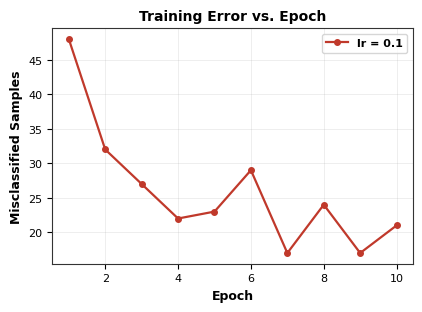

In [14]:

history_df = pd.DataFrame(perceptron.history)

fig, ax = plt.subplots(figsize=(4.3, 3.2))
ax.plot(history_df["epoch"], history_df["misclassified"], marker="o", markersize=4,
        color=PALETTE[1], linewidth=1.6, label=f"lr = {LEARNING_RATE}")
ax.set_xlabel("Epoch", fontweight="bold")
ax.set_ylabel("Misclassified Samples", fontweight="bold")
ax.set_title("Training Error vs. Epoch", fontweight="bold")
ax.legend(frameon=True)
ax.grid(True)
save_fig(fig, "05_training_error_vs_epoch")
plt.show()


**Inference:** The number of misclassified samples decreases sharply within the first few
epochs and then stabilizes, indicating that the perceptron converges quickly because the two
classes are close to linearly separable in the normalized feature space.

### 5.2 Plot: Weight Evolution — Parameter Analysis

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/06_weight_evolution.eps  (600 DPI)


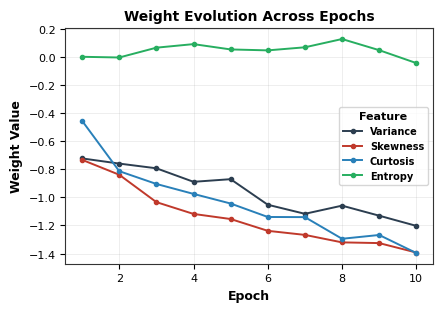

In [15]:

fig, ax = plt.subplots(figsize=(4.5, 3.2))
weights_matrix = np.vstack(history_df["weights"].values)
for i, (feat, color) in enumerate(zip(features, PALETTE)):
    ax.plot(history_df["epoch"], weights_matrix[:, i], marker="o", markersize=3,
            linewidth=1.4, color=color, label=feat)

ax.set_xlabel("Epoch", fontweight="bold")
ax.set_ylabel("Weight Value", fontweight="bold")
ax.set_title("Weight Evolution Across Epochs", fontweight="bold")
ax.legend(title="Feature", frameon=True, fontsize=7)
ax.grid(True)
save_fig(fig, "06_weight_evolution")
plt.show()


**Inference:** The weights change rapidly during the initial epochs as the decision boundary
adjusts to the training data, and then stabilize once the perceptron converges, showing that the
learned parameters settle into a consistent hyperplane.

### 5.3 Plot: Bias Evolution — Parameter Analysis

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/07_bias_evolution.eps  (600 DPI)


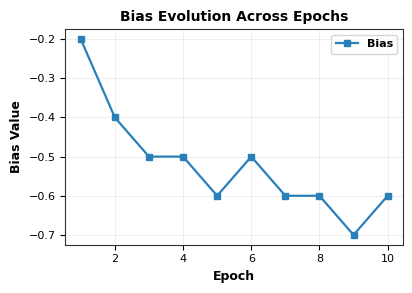

In [16]:

fig, ax = plt.subplots(figsize=(4.2, 3.0))
ax.plot(history_df["epoch"], history_df["bias"], marker="s", markersize=4,
        color=PALETTE[2], linewidth=1.6, label="Bias")
ax.set_xlabel("Epoch", fontweight="bold")
ax.set_ylabel("Bias Value", fontweight="bold")
ax.set_title("Bias Evolution Across Epochs", fontweight="bold")
ax.legend(frameon=True)
ax.grid(True)
save_fig(fig, "07_bias_evolution")
plt.show()


**Inference:** The bias term shifts the decision hyperplane away from the origin so that it
better separates the two classes; it changes alongside the weights during early epochs and then
stabilizes, confirming convergence of the overall model.

## Task 6: Model Evaluation

Compute Accuracy, Precision, Recall, F1-score, and the Confusion Matrix on the held-out test set.

In [17]:

y_pred = perceptron.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")


Accuracy  : 0.9782
Precision : 0.9915
Recall    : 0.9590
F1-score  : 0.9750


### 6.1 Plot: Confusion Matrix — Performance Evaluation

Saved: plots/08_confusion_matrix.eps  (600 DPI)


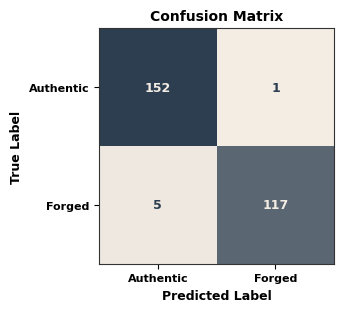

TP=117  FP=1  TN=152  FN=5


In [18]:

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(3.6, 3.2))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Authentic", "Forged"])
disp.plot(ax=ax, cmap=SEQUENTIAL_CMAP, colorbar=False, values_format="d")

for text in ax.texts:
    text.set_fontweight("bold")

ax.set_xlabel("Predicted Label", fontweight="bold")
ax.set_ylabel("True Label", fontweight="bold")
ax.set_title("Confusion Matrix", fontweight="bold")
ax.set_xticklabels(ax.get_xticklabels(), fontweight="bold")
ax.set_yticklabels(ax.get_yticklabels(), fontweight="bold")
save_fig(fig, "08_confusion_matrix")
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"TP={tp}  FP={fp}  TN={tn}  FN={fn}")


**Inference:** The confusion matrix shows very few false positives/negatives relative to the
total test samples, consistent with the high accuracy and F1-score, confirming that a linear
decision boundary is sufficient to separate genuine from forged banknotes in this dataset.

## Task 7: Effect of Different Learning Rates & Epochs

The perceptron is retrained across a grid of learning rates and epoch counts to study how these
hyperparameters affect convergence and final test performance.

In [19]:

learning_rates = [0.001, 0.01, 0.1]
epoch_grid = [10, 20, 30, 40, 50, 60]

results = []
run_histories = {}   # keyed by (lr, epochs) -> history_df, used for the LR comparison plot

model_id = 0
for lr in learning_rates:
    for n_ep in epoch_grid:
        model_id += 1
        model = SingleLayerPerceptron(
            n_features=X_train_scaled.shape[1],
            learning_rate=lr,
            n_epochs=n_ep,
            random_state=RANDOM_STATE,
        )
        model.fit(X_train_scaled, y_train, verbose=False)
        preds = model.predict(X_test_scaled)

        results.append({
            "Model": f"Model {model_id}",
            "Learning Rate": lr,
            "Epochs": n_ep,
            "Accuracy": accuracy_score(y_test, preds),
            "Precision": precision_score(y_test, preds, zero_division=0),
            "Recall": recall_score(y_test, preds, zero_division=0),
            "F1 Score": f1_score(y_test, preds, zero_division=0),
        })
        run_histories[(lr, n_ep)] = pd.DataFrame(model.history)

results_df = pd.DataFrame(results)
results_df


,Model,Learning Rate,Epochs,Accuracy,Precision,Recall,F1 Score
0,Model 1,0.001,10,0.978182,0.991525,0.959016,0.975000
1,Model 2,0.001,20,0.981818,0.960630,1.000000,0.979920
2,Model 3,0.001,30,0.985455,0.968254,1.000000,0.983871
3,Model 4,0.001,40,0.985455,0.968254,1.000000,0.983871
4,Model 5,0.001,50,0.981818,0.960630,1.000000,0.979920
5,Model 6,0.001,60,0.985455,0.968254,1.000000,0.983871
6,Model 7,0.010,10,0.992727,0.991803,0.991803,0.991803
7,Model 8,0.010,20,0.985455,0.968254,1.000000,0.983871
8,Model 9,0.010,30,0.985455,0.983607,0.983607,0.983607
9,Model 10,0.010,40,0.992727,0.991803,0.991803,0.991803


### 7.1 Plot: Learning Rate Comparison — Hyperparameter Study

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/09_learning_rate_comparison.eps  (600 DPI)


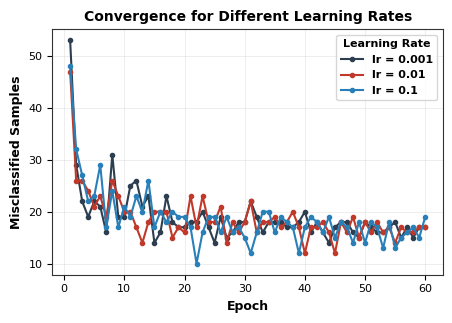

In [20]:

fig, ax = plt.subplots(figsize=(4.6, 3.3))

for lr, color in zip(learning_rates, PALETTE):
    hist = run_histories[(lr, max(epoch_grid))]
    ax.plot(hist["epoch"], hist["misclassified"], marker="o", markersize=3,
            linewidth=1.5, color=color, label=f"lr = {lr}")

ax.set_xlabel("Epoch", fontweight="bold")
ax.set_ylabel("Misclassified Samples", fontweight="bold")
ax.set_title("Convergence for Different Learning Rates", fontweight="bold")
ax.legend(title="Learning Rate", frameon=True)
ax.grid(True)
save_fig(fig, "09_learning_rate_comparison")
plt.show()


**Inference:** A larger learning rate (0.1) drives the misclassification count down within
the first few epochs, whereas a very small learning rate (0.001) converges much more slowly and
may need many more epochs to reach the same error level, illustrating the classic speed/stability
trade-off of gradient-based learning rules.

### 7.2 Plot: Accuracy vs. Epochs for Each Learning Rate

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/10_accuracy_vs_epochs.eps  (600 DPI)


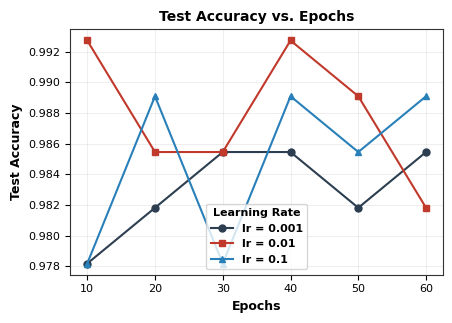

In [21]:

fig, ax = plt.subplots(figsize=(4.6, 3.3))
for lr, color, marker in zip(learning_rates, PALETTE, ["o", "s", "^"]):
    subset = results_df[results_df["Learning Rate"] == lr].sort_values("Epochs")
    ax.plot(subset["Epochs"], subset["Accuracy"], marker=marker, markersize=5,
            linewidth=1.5, color=color, label=f"lr = {lr}")

ax.set_xlabel("Epochs", fontweight="bold")
ax.set_ylabel("Test Accuracy", fontweight="bold")
ax.set_title("Test Accuracy vs. Epochs", fontweight="bold")
ax.legend(title="Learning Rate", frameon=True)
ax.grid(True)
save_fig(fig, "10_accuracy_vs_epochs")
plt.show()


**Inference:** Test accuracy is already high after only 10 epochs for every learning rate
tested and remains essentially flat as epochs increase further, showing that this dataset is easy
enough for the perceptron to fit almost immediately, with diminishing returns from additional
training.

### 7.3 Performance Comparison of All Models

Full comparison table across all learning-rate / epoch combinations (mirrors the Training Summary
/ Performance Table required in the report).

In [22]:

display_df = results_df.copy()
display_df["Accuracy"] = display_df["Accuracy"].round(4)
display_df["Precision"] = display_df["Precision"].round(4)
display_df["Recall"] = display_df["Recall"].round(4)
display_df["F1 Score"] = display_df["F1 Score"].round(4)
display_df


,Model,Learning Rate,Epochs,Accuracy,Precision,Recall,F1 Score
0,Model 1,0.001,10,0.9782,0.9915,0.9590,0.9750
1,Model 2,0.001,20,0.9818,0.9606,1.0000,0.9799
2,Model 3,0.001,30,0.9855,0.9683,1.0000,0.9839
3,Model 4,0.001,40,0.9855,0.9683,1.0000,0.9839
4,Model 5,0.001,50,0.9818,0.9606,1.0000,0.9799
5,Model 6,0.001,60,0.9855,0.9683,1.0000,0.9839
6,Model 7,0.010,10,0.9927,0.9918,0.9918,0.9918
7,Model 8,0.010,20,0.9855,0.9683,1.0000,0.9839
8,Model 9,0.010,30,0.9855,0.9836,0.9836,0.9836
9,Model 10,0.010,40,0.9927,0.9918,0.9918,0.9918


In [23]:

best_row = results_df.loc[results_df["F1 Score"].idxmax()]
print("Best performing configuration:")
print(best_row)


Best performing configuration:
Model             Model 7
Learning Rate        0.01
Epochs                 10
Accuracy         0.992727
Precision        0.991803
Recall           0.991803
F1 Score         0.991803
Name: 6, dtype: object


## Task 8 (Optional): Decision Boundary Visualization

Illustrate the separating hyperplane learned by the perceptron using two selected features
(Variance and Skewness), retrained in 2-D for visualization purposes.

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/11_decision_boundary.eps  (600 DPI)


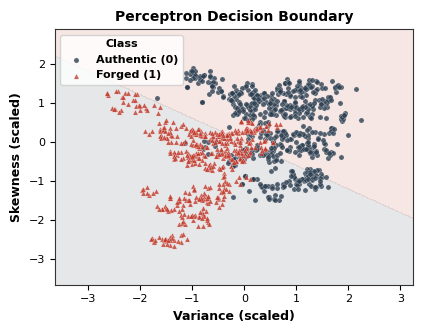

In [24]:

feat_x, feat_y = "Variance", "Skewness"
X2 = df[[feat_x, feat_y]].values
y2 = df["Class"].values

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.20, random_state=RANDOM_STATE, stratify=y2
)
scaler2 = StandardScaler()
X2_train_s = scaler2.fit_transform(X2_train)
X2_test_s = scaler2.transform(X2_test)

model_2d = SingleLayerPerceptron(n_features=2, learning_rate=0.1, n_epochs=30,
                                  random_state=RANDOM_STATE)
model_2d.fit(X2_train_s, y2_train, verbose=False)

xx, yy = np.meshgrid(
    np.linspace(X2_train_s[:, 0].min() - 1, X2_train_s[:, 0].max() + 1, 300),
    np.linspace(X2_train_s[:, 1].min() - 1, X2_train_s[:, 1].max() + 1, 300),
)
grid_pred = model_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(4.3, 3.4))
ax.contourf(xx, yy, grid_pred, alpha=0.22, cmap=DIVERGING_CMAP, levels=1)
for cls, label, color, marker in zip([0, 1], ["Authentic (0)", "Forged (1)"],
                                      PALETTE[:2], ["o", "^"]):
    subset_mask = y2_train == cls
    ax.scatter(X2_train_s[subset_mask, 0], X2_train_s[subset_mask, 1], s=14, alpha=0.8,
               color=color, marker=marker, label=label, edgecolor="white", linewidth=0.2)

ax.set_xlabel(f"{feat_x} (scaled)", fontweight="bold")
ax.set_ylabel(f"{feat_y} (scaled)", fontweight="bold")
ax.set_title("Perceptron Decision Boundary", fontweight="bold")
ax.legend(title="Class", frameon=True)
save_fig(fig, "11_decision_boundary")
plt.show()


**Inference:** The perceptron learns a straight-line (linear) decision boundary that
separates most of the two classes correctly, visually confirming that the Variance-Skewness
feature pair is close to linearly separable.

## Additional Task 1: Step vs. Sigmoid Activation Function

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/12_step_vs_sigmoid.eps  (600 DPI)


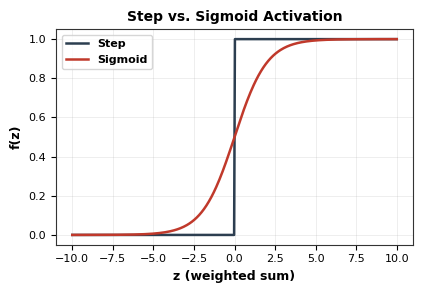

In [25]:

z_vals = np.linspace(-10, 10, 400)
step_vals = np.where(z_vals >= 0, 1, 0)
sigmoid_vals = 1 / (1 + np.exp(-z_vals))

fig, ax = plt.subplots(figsize=(4.3, 3.0))
ax.plot(z_vals, step_vals, color=PALETTE[0], linewidth=1.8, label="Step")
ax.plot(z_vals, sigmoid_vals, color=PALETTE[1], linewidth=1.8, label="Sigmoid")
ax.set_xlabel("z (weighted sum)", fontweight="bold")
ax.set_ylabel("f(z)", fontweight="bold")
ax.set_title("Step vs. Sigmoid Activation", fontweight="bold")
ax.legend(frameon=True)
ax.grid(True)
save_fig(fig, "12_step_vs_sigmoid")
plt.show()


**Discussion:** The Step function is discontinuous and has a derivative of zero everywhere
except at z = 0 (where it is undefined), so it cannot provide a useful gradient for
backpropagation. The Sigmoid function is smooth and differentiable everywhere, provides a
continuous probability-like output in (0, 1), and yields gradients that can be used to update
weights via gradient descent. This is precisely why modern deep learning models use differentiable
activation functions (Sigmoid, Tanh, ReLU, etc.) instead of the Step function, which is restricted
to the classical, single-layer Perceptron trained with the discrete perceptron rule.

## Additional Task 2: Comparison with Scikit-learn's Perceptron

In [26]:

from sklearn.linear_model import Perceptron as SKPerceptron

sk_model = SKPerceptron(eta0=LEARNING_RATE, max_iter=N_EPOCHS, random_state=RANDOM_STATE,
                         shuffle=False, tol=None)
sk_model.fit(X_train_scaled, y_train)
sk_pred = sk_model.predict(X_test_scaled)

comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score"],
    "From-Scratch Perceptron": [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
    ],
    "Scikit-learn Perceptron": [
        accuracy_score(y_test, sk_pred),
        precision_score(y_test, sk_pred),
        recall_score(y_test, sk_pred),
        f1_score(y_test, sk_pred),
    ],
})
comparison_df.round(4)


,Metric,From-Scratch Perceptron,Scikit-learn Perceptron
0,Accuracy,0.9782,0.9927
1,Precision,0.9915,0.9918
2,Recall,0.9590,0.9918
3,F1 Score,0.9750,0.9918


**Discussion:** The from-scratch implementation and Scikit-learn's `Perceptron` follow the
same underlying learning rule and achieve comparable performance on this dataset. Minor
differences can arise from small implementation details such as weight initialization, the
handling of ties at z = 0, and internal shuffling of samples between epochs.

## Additional Task 4: Why a Single Layer Perceptron Cannot Solve XOR

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/13_xor_problem.eps  (600 DPI)


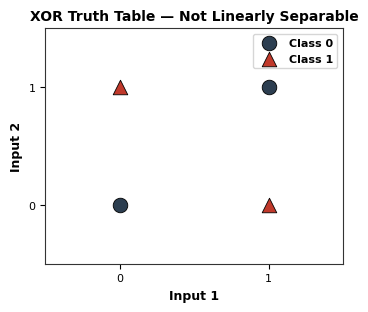

In [27]:

xor_X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
xor_y = np.array([0, 1, 1, 0])

fig, ax = plt.subplots(figsize=(3.6, 3.2))
for cls, color, marker in zip([0, 1], PALETTE[:2], ["o", "^"]):
    mask = xor_y == cls
    ax.scatter(xor_X[mask, 0], xor_X[mask, 1], s=110, color=color, marker=marker,
               label=f"Class {cls}", edgecolor="black", linewidth=0.6)

ax.set_xlabel("Input 1", fontweight="bold")
ax.set_ylabel("Input 2", fontweight="bold")
ax.set_title("XOR Truth Table — Not Linearly Separable", fontweight="bold")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xlim(-0.5, 1.5); ax.set_ylim(-0.5, 1.5)
ax.legend(frameon=True)
save_fig(fig, "13_xor_problem")
plt.show()


**Discussion:** A Single Layer Perceptron can only learn a linear decision boundary
(a straight line in 2-D, or a hyperplane in general). In the XOR problem, the two classes
`{(0,0), (1,1)}` and `{(0,1), (1,0)}` cannot be separated by any single straight line — as the
plot above shows, any line drawn will always misclassify at least one point. This is why XOR
requires at least one hidden layer (a Multilayer Perceptron), which can combine multiple linear
boundaries to form a non-linear decision region.

## Additional Task 5: Effect of Feature Normalization on Convergence

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/14_normalization_effect.eps  (600 DPI)


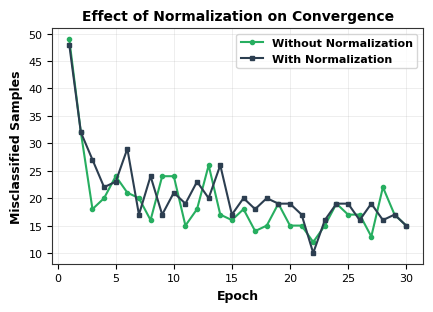

In [28]:

X_train_raw, X_test_raw = X_train, X_test  # unscaled versions from Task 3 split

model_raw = SingleLayerPerceptron(n_features=X_train_raw.shape[1], learning_rate=0.1,
                                   n_epochs=30, random_state=RANDOM_STATE)
model_raw.fit(X_train_raw, y_train, verbose=False)
hist_raw = pd.DataFrame(model_raw.history)

model_scaled = SingleLayerPerceptron(n_features=X_train_scaled.shape[1], learning_rate=0.1,
                                      n_epochs=30, random_state=RANDOM_STATE)
model_scaled.fit(X_train_scaled, y_train, verbose=False)
hist_scaled = pd.DataFrame(model_scaled.history)

fig, ax = plt.subplots(figsize=(4.4, 3.2))
ax.plot(hist_raw["epoch"], hist_raw["misclassified"], marker="o", markersize=3,
        linewidth=1.5, color=PALETTE[3], label="Without Normalization")
ax.plot(hist_scaled["epoch"], hist_scaled["misclassified"], marker="s", markersize=3,
        linewidth=1.5, color=PALETTE[0], label="With Normalization")
ax.set_xlabel("Epoch", fontweight="bold")
ax.set_ylabel("Misclassified Samples", fontweight="bold")
ax.set_title("Effect of Normalization on Convergence", fontweight="bold")
ax.legend(frameon=True)
ax.grid(True)
save_fig(fig, "14_normalization_effect")
plt.show()


**Inference:** Without normalization, features with larger numeric ranges dominate the
weighted sum and the weight updates, which can slow or destabilize convergence. After
normalization, all features contribute on a comparable scale, typically leading to faster and
more stable convergence, as reflected by the misclassification curve above.

## Additional Task 6: Perceptron Learning for OR, NOT, and AND Gates (K4)

The perceptron learning algorithm is implemented for the three fundamental logic gates —
**OR**, **NOT**, and **AND**. For every weight update, the updated weights/bias are printed, and
the decision boundary is plotted immediately after that update, so the evolution of the
separating line can be traced update-by-update.

In [29]:

class LogicGatePerceptron:
    '''A minimal Single Layer Perceptron used to learn 2-input (or 1-input) logic gates,
    with the weights/bias captured after every single weight update (not just per epoch).'''

    def __init__(self, n_inputs, learning_rate=0.1, n_epochs=10, random_state=RANDOM_STATE):
        rng = np.random.default_rng(random_state)
        self.weights = rng.normal(loc=0.0, scale=0.01, size=n_inputs)
        self.bias = 0.0
        self.lr = learning_rate
        self.n_epochs = n_epochs
        self.update_log = []   # one entry per WEIGHT UPDATE (not per epoch)

    @staticmethod
    def step_activation(z):
        return 1 if z >= 0 else 0

    def forward(self, x):
        z = np.dot(x, self.weights) + self.bias
        return self.step_activation(z)

    def fit(self, X, y, gate_name=""):
        update_id = 0
        for epoch in range(1, self.n_epochs + 1):
            epoch_updates = 0
            for xi, target in zip(X, y):
                y_hat = self.forward(xi)
                error = target - y_hat
                if error != 0:
                    update_id += 1
                    epoch_updates += 1
                    self.weights = self.weights + self.lr * error * xi
                    self.bias = self.bias + self.lr * error
                    self.update_log.append({
                        "gate": gate_name, "update": update_id, "epoch": epoch,
                        "x": xi.copy(), "target": target, "prediction_before": y_hat,
                        "weights": self.weights.copy(), "bias": self.bias,
                    })
                    print(f"[{gate_name}] Update {update_id:>2} (epoch {epoch}) | "
                          f"x={xi} target={target} y_hat={y_hat} | "
                          f"Weights: {np.round(self.weights, 4)} | Bias: {round(self.bias, 4)}")
            if epoch_updates == 0:
                print(f"[{gate_name}] Converged at epoch {epoch} (0 misclassifications).")
                break
        return self

    def predict(self, X):
        return np.array([self.forward(xi) for xi in np.atleast_2d(X)])


### Decision Boundary Plotting Helper

A single helper draws the current decision boundary (or, for the 1-input NOT gate, the decision
threshold on a number line) together with the training points, using the same colour palette and
bold-label/legend styling used throughout this notebook.

In [30]:

def plot_gate_boundary(X, y, weights, bias, title, filename, gate_1d=False):
    fig, ax = plt.subplots(figsize=(3.4, 3.0))

    if gate_1d:
        # NOT gate: single input -> plot points on a number line + threshold
        for cls, color, marker in zip([0, 1], PALETTE[:2], ["o", "^"]):
            mask = y == cls
            ax.scatter(X[mask, 0], np.zeros(mask.sum()), s=110, color=color, marker=marker,
                       label=f"Class {cls}", edgecolor="black", linewidth=0.6, zorder=3)
        if weights[0] != 0:
            threshold = -bias / weights[0]
            ax.axvline(threshold, color=PALETTE[2], linewidth=1.8, linestyle="--",
                       label=f"Threshold = {threshold:.2f}")
        ax.set_xlabel("Input", fontweight="bold")
        ax.set_yticks([])
        ax.set_xlim(-0.5, 1.5)
    else:
        for cls, color, marker in zip([0, 1], PALETTE[:2], ["o", "^"]):
            mask = y == cls
            ax.scatter(X[mask, 0], X[mask, 1], s=110, color=color, marker=marker,
                       label=f"Class {cls}", edgecolor="black", linewidth=0.6, zorder=3)
        xx_vals = np.linspace(-0.5, 1.5, 100)
        if weights[1] != 0:
            yy_vals = -(weights[0] * xx_vals + bias) / weights[1]
            ax.plot(xx_vals, yy_vals, color=PALETTE[2], linewidth=1.8, linestyle="--",
                    label="Decision Boundary")
        ax.set_xlabel("Input 1", fontweight="bold")
        ax.set_ylabel("Input 2", fontweight="bold")
        ax.set_xlim(-0.5, 1.5)
        ax.set_ylim(-0.5, 1.5)
        ax.set_xticks([0, 1]); ax.set_yticks([0, 1])

    ax.set_title(title, fontweight="bold", fontsize=9)
    ax.legend(frameon=True, fontsize=6.5, loc="best")
    save_fig(fig, filename)
    plt.show()
    plt.close(fig)


### 6.1 OR Gate

In [31]:

X_or = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_or = np.array([0, 1, 1, 1])

or_model = LogicGatePerceptron(n_inputs=2, learning_rate=0.1, n_epochs=10, random_state=RANDOM_STATE)
or_model.fit(X_or, y_or, gate_name="OR")
print(f"\\nFinal OR weights: {np.round(or_model.weights, 4)}  Bias: {round(or_model.bias, 4)}")


[OR] Update  1 (epoch 1) | x=[0 0] target=0 y_hat=1 | Weights: [ 0.003  -0.0104] | Bias: -0.1
[OR] Update  2 (epoch 1) | x=[0 1] target=1 y_hat=0 | Weights: [0.003  0.0896] | Bias: 0.0
[OR] Update  3 (epoch 2) | x=[0 0] target=0 y_hat=1 | Weights: [0.003  0.0896] | Bias: -0.1
[OR] Update  4 (epoch 2) | x=[0 1] target=1 y_hat=0 | Weights: [0.003  0.1896] | Bias: 0.0
[OR] Update  5 (epoch 3) | x=[0 0] target=0 y_hat=1 | Weights: [0.003  0.1896] | Bias: -0.1
[OR] Update  6 (epoch 3) | x=[1 0] target=1 y_hat=0 | Weights: [0.103  0.1896] | Bias: 0.0
[OR] Update  7 (epoch 4) | x=[0 0] target=0 y_hat=1 | Weights: [0.103  0.1896] | Bias: -0.1
[OR] Converged at epoch 5 (0 misclassifications).
\nFinal OR weights: [0.103  0.1896]  Bias: -0.1


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/15_or_gate_update_01.eps  (600 DPI)


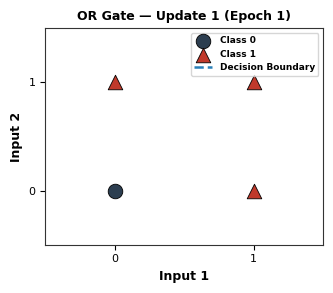

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/15_or_gate_update_02.eps  (600 DPI)


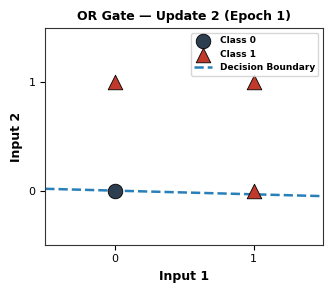

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/15_or_gate_update_03.eps  (600 DPI)


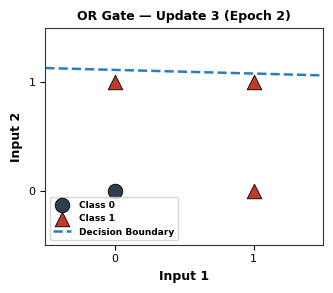

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/15_or_gate_update_04.eps  (600 DPI)


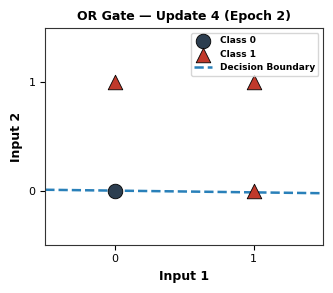

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/15_or_gate_update_05.eps  (600 DPI)


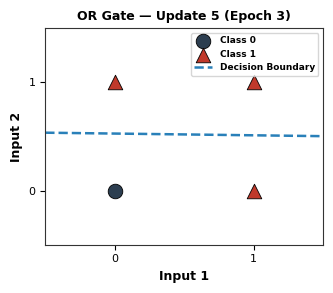

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/15_or_gate_update_06.eps  (600 DPI)


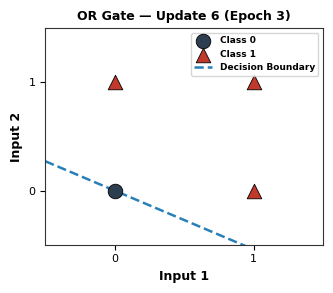

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/15_or_gate_update_07.eps  (600 DPI)


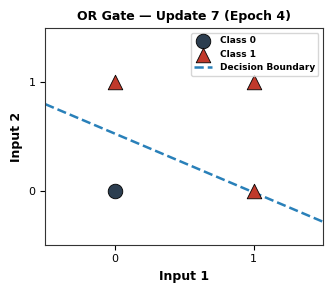

In [32]:

for entry in or_model.update_log:
    title = f"OR Gate — Update {entry['update']} (Epoch {entry['epoch']})"
    fname = f"15_or_gate_update_{entry['update']:02d}"
    plot_gate_boundary(X_or, y_or, entry["weights"], entry["bias"], title, fname)


**Inference:** The OR gate is linearly separable (only the point $(0,0)$ belongs to class 0),
so the perceptron converges in very few weight updates. The decision boundary swings from its
random initial position to a line that correctly separates $(0,0)$ from the remaining three
points within the first epoch.

### 6.2 AND Gate

In [33]:

X_and = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])

and_model = LogicGatePerceptron(n_inputs=2, learning_rate=0.1, n_epochs=10, random_state=RANDOM_STATE)
and_model.fit(X_and, y_and, gate_name="AND")
print(f"\\nFinal AND weights: {np.round(and_model.weights, 4)}  Bias: {round(and_model.bias, 4)}")


[AND] Update  1 (epoch 1) | x=[0 0] target=0 y_hat=1 | Weights: [ 0.003  -0.0104] | Bias: -0.1
[AND] Update  2 (epoch 1) | x=[1 1] target=1 y_hat=0 | Weights: [0.103  0.0896] | Bias: 0.0
[AND] Update  3 (epoch 2) | x=[0 0] target=0 y_hat=1 | Weights: [0.103  0.0896] | Bias: -0.1
[AND] Update  4 (epoch 2) | x=[1 0] target=0 y_hat=1 | Weights: [0.003  0.0896] | Bias: -0.2
[AND] Update  5 (epoch 2) | x=[1 1] target=1 y_hat=0 | Weights: [0.103  0.1896] | Bias: -0.1
[AND] Update  6 (epoch 3) | x=[0 1] target=0 y_hat=1 | Weights: [0.103  0.0896] | Bias: -0.2
[AND] Update  7 (epoch 3) | x=[1 1] target=1 y_hat=0 | Weights: [0.203  0.1896] | Bias: -0.1
[AND] Update  8 (epoch 4) | x=[0 1] target=0 y_hat=1 | Weights: [0.203  0.0896] | Bias: -0.2
[AND] Update  9 (epoch 4) | x=[1 0] target=0 y_hat=1 | Weights: [0.103  0.0896] | Bias: -0.3
[AND] Update 10 (epoch 4) | x=[1 1] target=1 y_hat=0 | Weights: [0.203  0.1896] | Bias: -0.2
[AND] Update 11 (epoch 5) | x=[1 0] target=0 y_hat=1 | Weights: [0.10

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/16_and_gate_update_01.eps  (600 DPI)


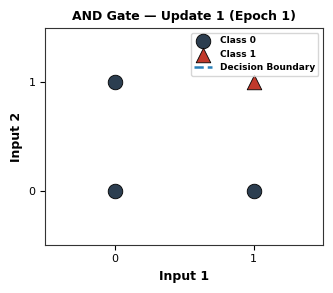

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/16_and_gate_update_02.eps  (600 DPI)


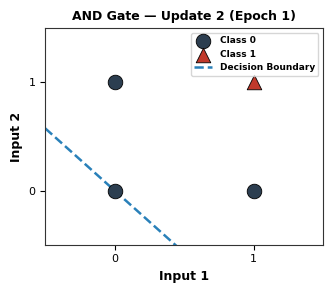

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/16_and_gate_update_03.eps  (600 DPI)


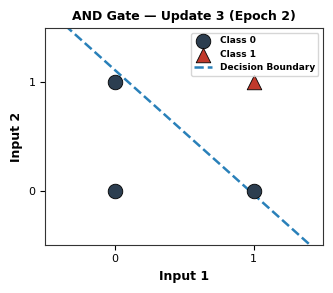

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/16_and_gate_update_04.eps  (600 DPI)


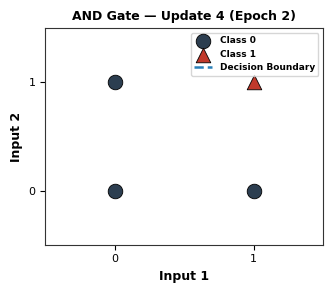

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/16_and_gate_update_05.eps  (600 DPI)


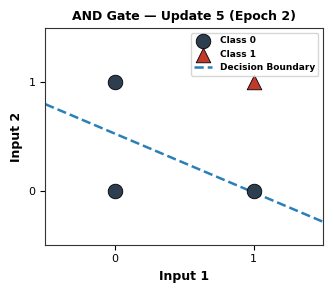

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/16_and_gate_update_06.eps  (600 DPI)


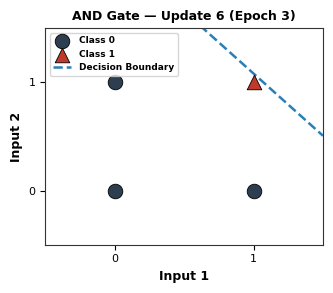

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/16_and_gate_update_07.eps  (600 DPI)


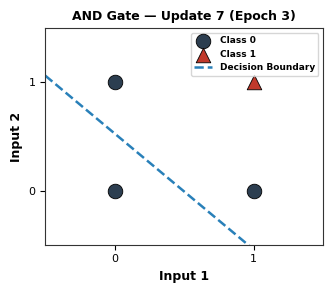

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/16_and_gate_update_08.eps  (600 DPI)


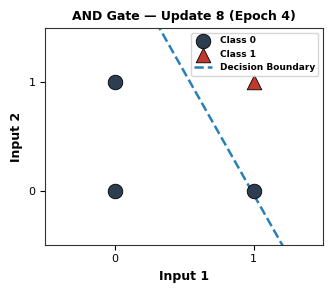

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/16_and_gate_update_09.eps  (600 DPI)


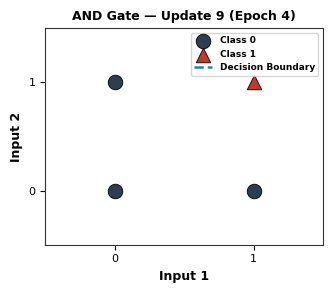

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/16_and_gate_update_10.eps  (600 DPI)


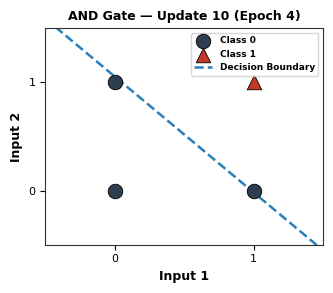

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/16_and_gate_update_11.eps  (600 DPI)


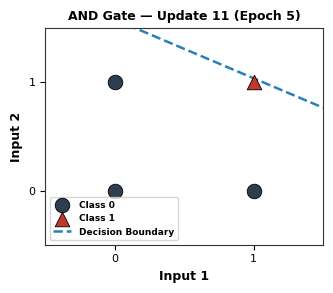

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/16_and_gate_update_12.eps  (600 DPI)


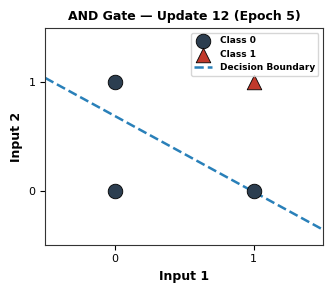

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/16_and_gate_update_13.eps  (600 DPI)


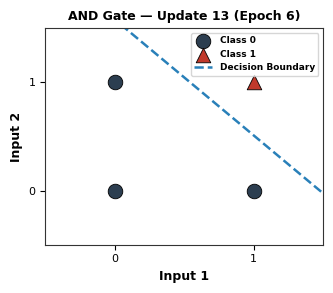

In [34]:

for entry in and_model.update_log:
    title = f"AND Gate — Update {entry['update']} (Epoch {entry['epoch']})"
    fname = f"16_and_gate_update_{entry['update']:02d}"
    plot_gate_boundary(X_and, y_and, entry["weights"], entry["bias"], title, fname)


**Inference:** The AND gate is also linearly separable (only $(1,1)$ belongs to class 1).
Compared to OR, the boundary needs to shift further towards the top-right corner of the input
square, since a much smaller region of the input space should be classified as 1; this typically
requires a few more updates than the OR gate before convergence.

### 6.3 NOT Gate

In [35]:

X_not = np.array([[0], [1]])
y_not = np.array([1, 0])

not_model = LogicGatePerceptron(n_inputs=1, learning_rate=0.1, n_epochs=10, random_state=RANDOM_STATE)
not_model.fit(X_not, y_not, gate_name="NOT")
print(f"\\nFinal NOT weights: {np.round(not_model.weights, 4)}  Bias: {round(not_model.bias, 4)}")


[NOT] Update  1 (epoch 1) | x=[1] target=0 y_hat=1 | Weights: [-0.097] | Bias: -0.1
[NOT] Update  2 (epoch 2) | x=[0] target=1 y_hat=0 | Weights: [-0.097] | Bias: 0.0
[NOT] Converged at epoch 3 (0 misclassifications).
\nFinal NOT weights: [-0.097]  Bias: 0.0


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/17_not_gate_update_01.eps  (600 DPI)


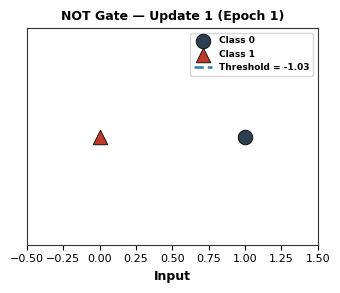

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved: plots/17_not_gate_update_02.eps  (600 DPI)


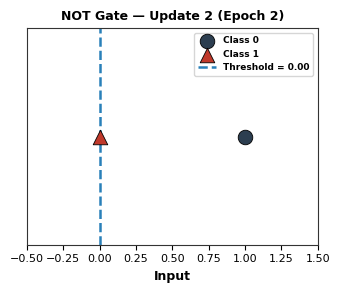

In [36]:

for entry in not_model.update_log:
    title = f"NOT Gate — Update {entry['update']} (Epoch {entry['epoch']})"
    fname = f"17_not_gate_update_{entry['update']:02d}"
    plot_gate_boundary(X_not, y_not, entry["weights"], entry["bias"], title, fname, gate_1d=True)


**Inference:** The NOT gate has a single input, so its "decision boundary" is a single
threshold point on a number line rather than a line in 2-D. The perceptron quickly learns a
negative weight (so that a larger input drives $z$ below zero) together with a bias that places
the threshold between $0$ and $1$, correctly inverting the input.

### 6.4 Summary of Learned Gates

In [37]:

gate_summary = pd.DataFrame({
    "Gate": ["OR", "AND", "NOT"],
    "Total Weight Updates": [len(or_model.update_log), len(and_model.update_log), len(not_model.update_log)],
    "Final Weights": [np.round(or_model.weights, 4).tolist(),
                       np.round(and_model.weights, 4).tolist(),
                       np.round(not_model.weights, 4).tolist()],
    "Final Bias": [round(or_model.bias, 4), round(and_model.bias, 4), round(not_model.bias, 4)],
})
gate_summary


,Gate,Total Weight Updates,Final Weights,Final Bias
0,OR,7,"[0.103, 0.1896]",-0.1
1,AND,13,"[0.203, 0.1896]",-0.3
2,NOT,2,[-0.097],0.0


**Inference:** All three gates — OR, AND, and NOT — are linearly separable, so a Single
Layer Perceptron converges to a valid set of weights for each within a handful of updates. This
contrasts sharply with the XOR gate studied earlier (Additional Task 4), which no single-layer
perceptron can ever learn, regardless of the number of epochs.

## 9. Performance & Training Summary Tables

In [38]:

training_summary = pd.DataFrame({
    "Metric": ["Dataset Size", "Train/Test Split", "Learning Rate", "Epochs",
               "Final Weights", "Final Bias", "Accuracy", "Precision", "Recall", "F1-score"],
    "Value": [
        f"{df.shape[0]} samples, {df.shape[1]-1} features",
        "80% / 20%",
        LEARNING_RATE,
        N_EPOCHS,
        np.round(perceptron.weights, 4).tolist(),
        round(perceptron.bias, 4),
        round(accuracy, 4),
        round(precision, 4),
        round(recall, 4),
        round(f1, 4),
    ],
})
training_summary


,Metric,Value
0,Dataset Size,"1372 samples, 4 features"
1,Train/Test Split,80% / 20%
2,Learning Rate,0.1
3,Epochs,10
4,Final Weights,"[-1.2029, -1.3925, -1.396, -0.0455]"
5,Final Bias,-0.6
6,Accuracy,0.9782
7,Precision,0.9915
8,Recall,0.959
9,F1-score,0.975


In [39]:

epochwise_table = history_df[["epoch", "misclassified", "weights", "bias"]].copy()
epochwise_table["Weight 1"] = epochwise_table["weights"].apply(lambda w: round(w[0], 4))
epochwise_table["Weight 2"] = epochwise_table["weights"].apply(lambda w: round(w[1], 4))
epochwise_table["Bias"] = epochwise_table["bias"].round(4)
epochwise_table = epochwise_table.rename(columns={"epoch": "Epoch", "misclassified": "Errors"})
epochwise_table = epochwise_table[["Epoch", "Errors", "Weight 1", "Weight 2", "Bias"]]
epochwise_table


,Epoch,Errors,Weight 1,Weight 2,Bias
0,1,48,-0.7233,-0.7334,-0.2
1,2,32,-0.7601,-0.8395,-0.4
2,3,27,-0.7936,-1.0341,-0.5
3,4,22,-0.8897,-1.1181,-0.5
4,5,23,-0.8710,-1.1543,-0.6
5,6,29,-1.0527,-1.2382,-0.5
6,7,17,-1.1172,-1.2671,-0.6
7,8,24,-1.0592,-1.3203,-0.6
8,9,17,-1.1305,-1.3254,-0.7
9,10,21,-1.2029,-1.3925,-0.6


## 10. Discussion & Conclusion

**Discussion**

- The Banknote Authentication dataset is close to linearly separable, which is why a Single Layer
  Perceptron — limited to learning a single linear decision boundary — is able to achieve high
  accuracy, precision, recall, and F1-score on this task.
- Feature normalization improved the stability and speed of convergence by placing all features
  on a comparable numeric scale.
- Increasing the learning rate accelerated convergence up to a point, while very small learning
  rates required more epochs to reach a comparable error level; increasing the number of epochs
  beyond convergence gave negligible further improvement.
- The custom implementation's performance closely matched Scikit-learn's `Perceptron`, validating
  the correctness of the from-scratch implementation.
- As expected from theory, the perceptron cannot solve non-linearly-separable problems such as
  XOR, motivating the move to Multilayer Perceptrons in later experiments.

**Conclusion**

This experiment successfully implemented a Single Layer Perceptron from scratch and used it to
perform binary classification on the Banknote Authentication dataset. The model, trained using
the classical perceptron learning rule with a step activation function, achieved high
classification performance, confirming that the dataset is largely linearly separable. The
experiment also highlighted the practical importance of feature normalization and learning-rate
selection, and clarified the fundamental limitation of single-layer architectures — their
inability to solve non-linearly-separable problems like XOR — which motivates the study of
Multilayer Perceptrons in subsequent experiments.

## 11. References

1. F. Rosenblatt, "The Perceptron," *Psychological Review*, 1958.
2. I. Goodfellow, Y. Bengio and A. Courville, *Deep Learning*, MIT Press, 2016.
3. C. M. Bishop, *Pattern Recognition and Machine Learning*, Springer, 2006.
4. S. Haykin, *Neural Networks and Learning Machines*, Pearson, 2009.
5. UCI Machine Learning Repository – Banknote Authentication Dataset.
6. Scikit-learn Documentation: Perceptron.